Support2 EDA 

Huibin Chang

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
support2 = fetch_ucirepo(id=880) 
  
# data (as pandas dataframes) 
X = support2.data.features 
y = support2.data.targets 
  
# metadata 
print(support2.metadata) 
  
# variable information 
print(support2.variables) 


{'uci_id': 880, 'name': 'SUPPORT2', 'repository_url': 'https://archive.ics.uci.edu/dataset/880/support2', 'data_url': 'https://archive.ics.uci.edu/static/public/880/data.csv', 'abstract': "This dataset comprises 9105 individual critically ill patients across 5 United States medical centers, accessioned throughout 1989-1991 and 1992-1994.\nEach row concerns hospitalized patient records who met the inclusion and exclusion criteria for nine disease categories: acute respiratory failure, chronic obstructive pulmonary disease, congestive heart failure, liver disease, coma, colon cancer, lung cancer, multiple organ system failure with malignancy, and multiple organ system failure with sepsis. The goal is to determine these patients' 2- and 6-month survival rates based on several physiologic, demographics, and disease severity information. \nIt is an important problem because it addresses the growing national concern over patients' loss of control near the end of life. It enables earlier deci

In [3]:
type(support2)
type(support2.data)
support2.data.features
type(support2.data.targets)
support2.data.targets.shape


support2.data.targets

,death,hospdead,sfdm2
0,0,0,NaN
1,1,1,<2 mo. follow-up
2,1,0,<2 mo. follow-up
3,1,0,no(M2 and SIP pres)
4,0,0,no(M2 and SIP pres)
...,...,...,...
9100,0,0,NaN
9101,0,0,NaN
9102,0,0,NaN
9103,1,1,<2 mo. follow-up


In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [5]:

# Concatenate together features and targest
df = pd.concat([support2.data.features, support2.data.targets], axis=1) 

# Take a look at datatypes and non-null counts
df.info()
support2.data.targets

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   object 
 2   dzgroup   9105 non-null   object 
 3   dzclass   9105 non-null   object 
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   object 
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   object 
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  
 20  ca        9105 non-null   obje

,death,hospdead,sfdm2
0,0,0,NaN
1,1,1,<2 mo. follow-up
2,1,0,<2 mo. follow-up
3,1,0,no(M2 and SIP pres)
4,0,0,no(M2 and SIP pres)
...,...,...,...
9100,0,0,NaN
9101,0,0,NaN
9102,0,0,NaN
9103,1,1,<2 mo. follow-up


In [6]:
# Print out unique values for some features - to check
print(f"Unique values for sex: {df.sex.unique()}")
print(50*"-")
print(f"Unique values for sex: {df.dzgroup.unique()}")

print(50*"-")
print(f"Unique values for sex: {df.dzclass.unique()}")

print(50*"-")
print(f"Unique values for edu: {df.edu.unique()}")

print(50*"-")
print(f"Unique values for income: {df.income.unique()}")

print(50*"-")
print(f"Unique values for race: {df.race.unique()}")

print(50*"-")
print(f"Unique values for ca (cancer): {df.ca.unique()}")


Unique values for sex: ['male' 'female']
--------------------------------------------------
Unique values for sex: ['Lung Cancer' 'Cirrhosis' 'ARF/MOSF w/Sepsis' 'Coma' 'CHF' 'Colon Cancer'
 'COPD' 'MOSF w/Malig']
--------------------------------------------------
Unique values for sex: ['Cancer' 'COPD/CHF/Cirrhosis' 'ARF/MOSF' 'Coma']
--------------------------------------------------
Unique values for edu: [11. 12. nan 14. 16. 22.  8. 13. 17. 19.  0. 10. 21.  6. 18. 15.  3. 20.
  2. 30.  9.  7. 27.  1.  4. 24. 23.  5. 31. 25. 26. 28.]
--------------------------------------------------
Unique values for income: ['$11-$25k' 'under $11k' nan '$25-$50k' '>$50k']
--------------------------------------------------
Unique values for race: ['other' 'white' 'black' 'hispanic' 'asian' nan]
--------------------------------------------------
Unique values for ca (cancer): ['metastatic' 'no' 'yes']


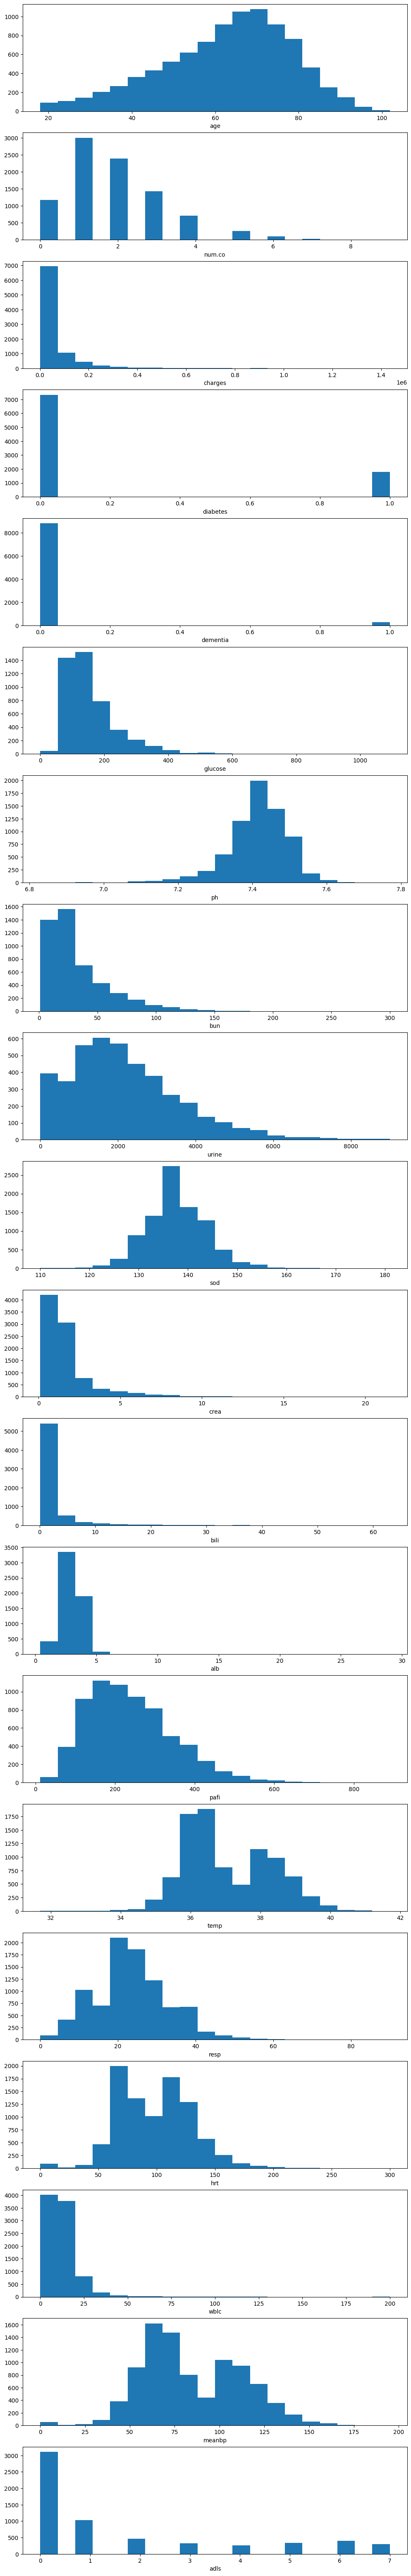

In [7]:
plotted_vars = [df.age, df['num.co'], df.charges,
                df.diabetes, df.dementia, df.glucose,
                df.ph, df.bun, df.urine, 
                df.sod, df.crea, df.bili,
                df.alb, df.pafi, df.temp, 
                df.resp, df.hrt, df.wblc,
                df.meanbp, df.adls]
fig, ax = plt.subplots(len(plotted_vars), 1,
                       figsize=(12,4 * len(plotted_vars)))

for idx in range(0, len(plotted_vars)):
    ax[idx].hist(plotted_vars[idx],
                 bins=20),
    ax[idx].set_xlabel(plotted_vars[idx].name)

In [8]:
df.columns
df[['death', 'hospdead']].tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   object 
 2   dzgroup   9105 non-null   object 
 3   dzclass   9105 non-null   object 
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   object 
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   object 
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  
 20  ca        9105 non-null   obje

In [9]:
#df.age.mean()
#df.age.info()
#df.age.max()

share_d = df.death.sum() / df.death.shape[0]
share_d

df.hospdead.sum() / df.death.shape[0]

df.age.quantile(0.1)
df.age.quantile(0.9)
df.sex[df.sex == 'female'].shape[0] / df.sex.shape[0] 
df.ca.value_counts(normalize=True)
#no_cancer_share = df.ca.value_counts()[0] / df.shape[0]
#metastatic_share = df.ca.value_counts()[1] / df.shape[0]
#can_share = df.ca.value_counts()[2] / df.shape[0]

ca
no            0.658429
metastatic    0.204064
yes           0.137507
Name: proportion, dtype: float64

In [16]:
display(df.columns)

import pprint

#df['num.co']
#df.slos
len(df.columns)
df.hday.describe()
df[df.hospdead == 1].hday.describe()

Index(['age', 'sex', 'dzgroup', 'dzclass', 'num.co', 'edu', 'income', 'scoma',
       'charges', 'totcst', 'totmcst', 'avtisst', 'race', 'sps', 'aps',
       'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'prg2m',
       'prg6m', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp',
       'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine',
       'adlp', 'adls', 'adlsc', 'death', 'hospdead', 'sfdm2'],
      dtype='object')

count    2360.000000
mean        7.698729
std        12.610996
min         1.000000
25%         1.000000
50%         2.000000
75%        10.000000
max       140.000000
Name: hday, dtype: float64

In [17]:
df_full = support2.data.original

In [24]:
df_full.slos.describe()
df_full[df.hospdead == 1].slos.describe()

count    2360.000000
mean       17.469492
std        21.839309
min         3.000000
25%         6.000000
50%        10.000000
75%        20.000000
max       339.000000
Name: slos, dtype: float64

In [25]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   object 
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   object 
 8   dzclass   9105 non-null   object 
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   object 
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   object 
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m    9104 non-null   floa